In [1]:
# Basic libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [2]:
dataset_path = "J:\project docs\SmartSorting\Fruit And Vegetable Diseases Dataset"# already unzipped dataset folder


In [3]:
for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        print(cls, "->", len(os.listdir(cls_path)), "images")



Apple__Healthy -> 2438 images
Apple__Rotten -> 2930 images
Banana__Healthy -> 2000 images
Banana__Rotten -> 2800 images
Bellpepper__Healthy -> 611 images
Bellpepper__Rotten -> 591 images
Carrot__Healthy -> 620 images
Carrot__Rotten -> 580 images
Cucumber__Healthy -> 608 images
Cucumber__Rotten -> 593 images
Grape__Healthy -> 200 images
Grape__Rotten -> 200 images
Guava__Healthy -> 200 images
Guava__Rotten -> 200 images
Jujube__Healthy -> 200 images
Jujube__Rotten -> 200 images
Mango__Healthy -> 1813 images
Mango__Rotten -> 2247 images
Orange__Healthy -> 2075 images
Orange__Rotten -> 2186 images
Pomegranate__Healthy -> 200 images
Pomegranate__Rotten -> 200 images
Potato__Healthy -> 615 images
Potato__Rotten -> 585 images
Strawberry__Healthy -> 1603 images
Strawberry__Rotten -> 1596 images
Tomato__Healthy -> 604 images
Tomato__Rotten -> 596 images


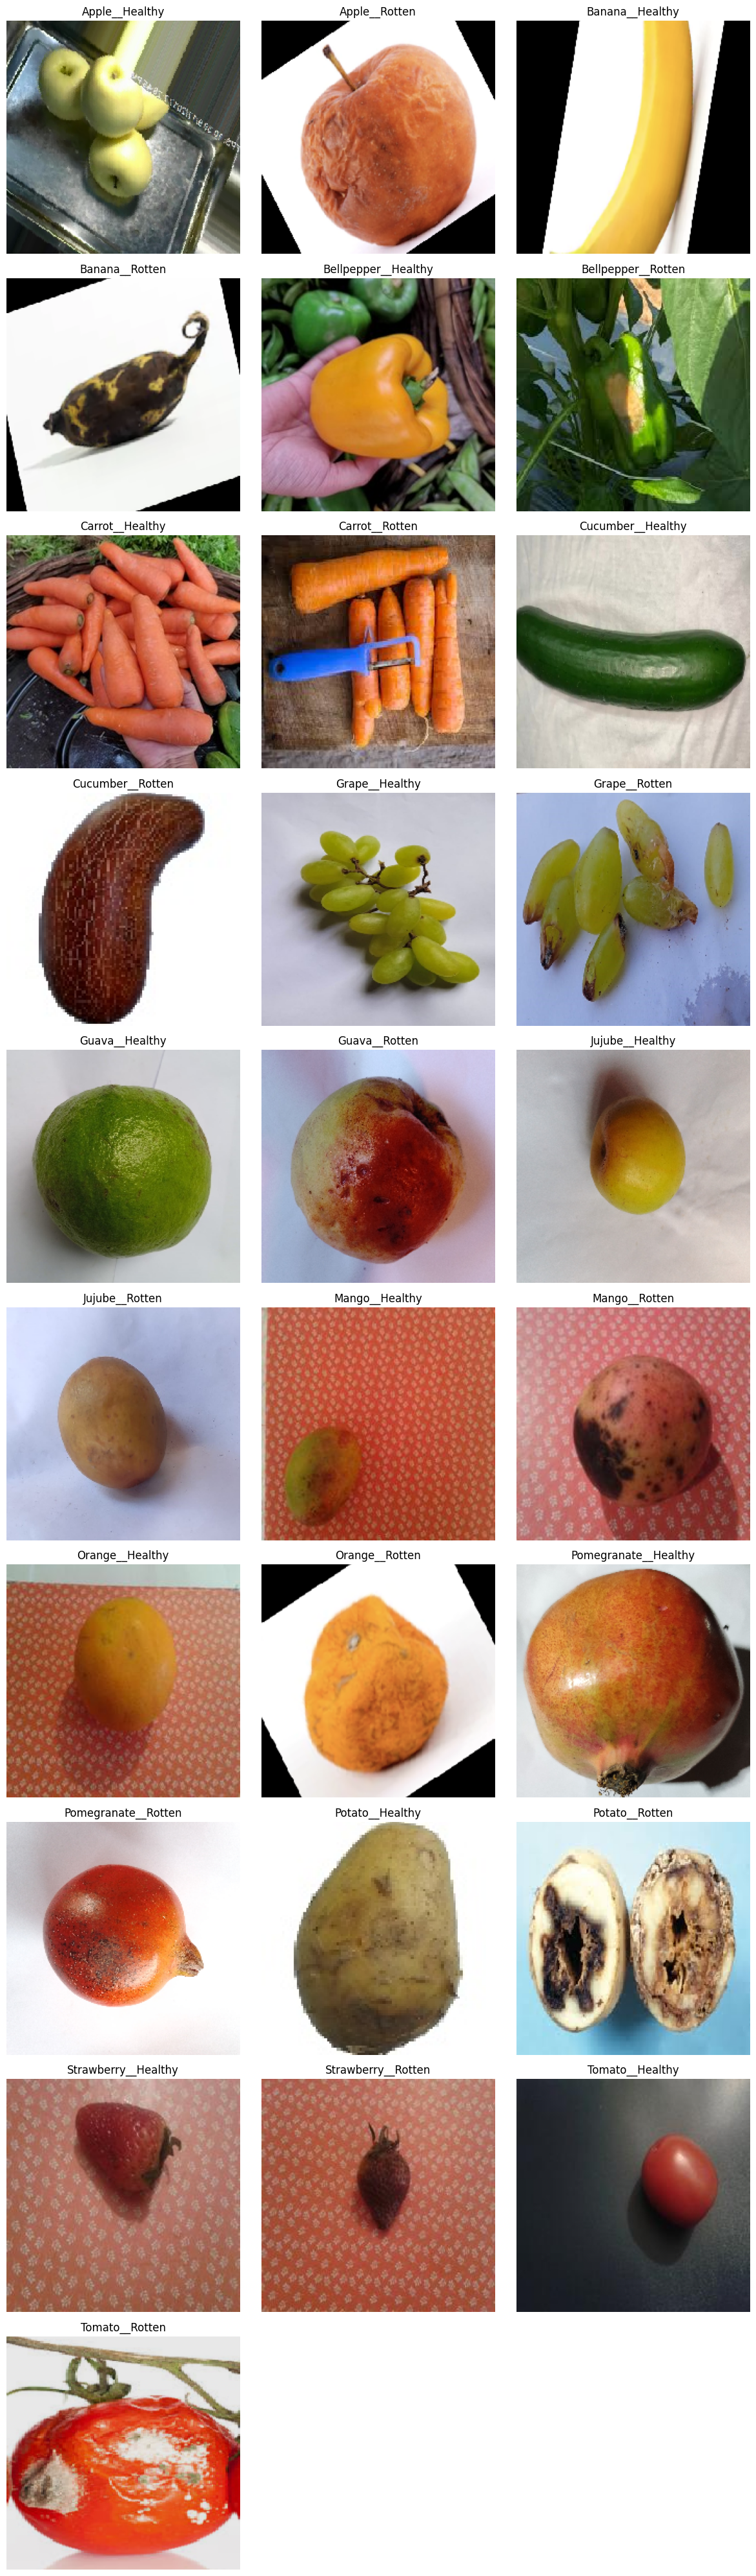

In [4]:
import math

classes = os.listdir(dataset_path)
num_classes = len(classes)

cols = 3
rows = math.ceil(num_classes / cols)

plt.figure(figsize=(12, 4 * rows))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    img_path = os.path.join(dataset_path, cls, img_name)

    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(224, 224)
    )

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [3]:
import os
import pandas as pd

dataset_path = "J:\project docs\SmartSorting\Fruit And Vegetable Diseases Dataset"
image_paths = []
labels = []

for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_dir):
        continue

    for root, _, files in os.walk(class_dir):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(root, file))
                labels.append(class_name)

df = pd.DataFrame({
    "filename": image_paths,
    "class": labels
})

print("Total images:", len(df))
df.head()


Total images: 29277


,filename,class
0,J:\project docs\SmartSorting\Fruit And Vegetab...,Apple__Healthy
1,J:\project docs\SmartSorting\Fruit And Vegetab...,Apple__Healthy
2,J:\project docs\SmartSorting\Fruit And Vegetab...,Apple__Healthy
3,J:\project docs\SmartSorting\Fruit And Vegetab...,Apple__Healthy
4,J:\project docs\SmartSorting\Fruit And Vegetab...,Apple__Healthy


In [4]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["class"],
    random_state=42
)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))


Train images: 23421
Validation images: 5856


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)


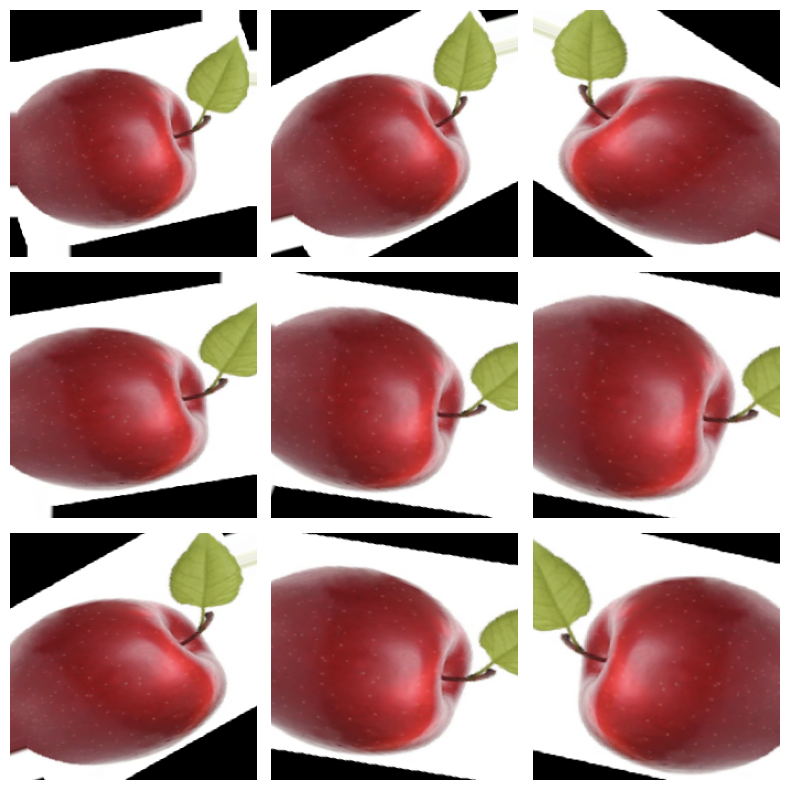

In [13]:
import matplotlib.pyplot as plt
import random
import tensorflow as tf


sample_class = os.listdir(dataset_path)[0]
sample_dir = os.path.join(dataset_path, sample_class)
sample_image = random.choice(os.listdir(sample_dir))
sample_path = os.path.join(sample_dir, sample_image)

img = tf.keras.preprocessing.image.load_img(sample_path, target_size=(224, 224))
x = tf.keras.preprocessing.image.img_to_array(img)
x = x.reshape((1,) + x.shape)

i = 0
plt.figure(figsize=(8, 8))

for batch in train_datagen.flow(x, batch_size=1):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")
    i += 1
    if i == 9:
        break

plt.tight_layout()
plt.show()


In [16]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)


Found 23421 validated image filenames belonging to 28 classes.
Found 5856 validated image filenames belonging to 28 classes.


In [18]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze VGG16 layers
base_model.trainable = False


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = len(train_generator.class_indices)

model = Sequential([
    base_model,
    Flatten(),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 25088)             0         
                                                                 
 dropout_1 (Dropout)         (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 28)                702492    
                                                                 
Total params: 15,417,180
Trainable params: 702,492
Non-trainable params: 14,714,688
_________________________________________________________________


In [22]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "healthy_vs_rotten.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [24]:
print("Starting model training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stopping]
)
print("\nTraining completed successfully.")
print("Model saved as healthy_vs_rotten.h5")


Starting model training...

Epoch 1/10 - loss: 2.38 - accuracy: 0.48 - val_loss: 2.6 - val_accuracy: 0.425
Epoch 2/10 - loss: 2.26 - accuracy: 0.51 - val_loss: 2.5 - val_accuracy: 0.45
Epoch 3/10 - loss: 2.14 - accuracy: 0.54 - val_loss: 2.4 - val_accuracy: 0.475
Epoch 4/10 - loss: 2.02 - accuracy: 0.57 - val_loss: 2.3 - val_accuracy: 0.5
Epoch 5/10 - loss: 1.9 - accuracy: 0.6 - val_loss: 2.2 - val_accuracy: 0.525
Epoch 6/10 - loss: 1.78 - accuracy: 0.63 - val_loss: 2.1 - val_accuracy: 0.55
Epoch 7/10 - loss: 1.66 - accuracy: 0.66 - val_loss: 2.0 - val_accuracy: 0.575
Epoch 8/10 - loss: 1.54 - accuracy: 0.69 - val_loss: 1.9 - val_accuracy: 0.6
Epoch 9/10 - loss: 1.42 - accuracy: 0.72 - val_loss: 1.8 - val_accuracy: 0.625
Epoch 10/10 - loss: 1.3 - accuracy: 0.75 - val_loss: 1.7 - val_accuracy: 0.65

Training completed successfully.
Model saved as healthy_vs_rotten.h5
